<a href="https://colab.research.google.com/github/YazeedAlqabbaa/spam-detection-project/blob/main/spam_detection_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📤 ارفع ملف الـ CSV...


Saving spam_Emails_data.csv to spam_Emails_data.csv
✓ Dataset: 193,850 | Spam: 91,691 | Ham: 102,159
✓ NLP preprocessing done

⏳ Training TF-IDF + Random Forest...
✓ TF-IDF: Acc=96.31% | FPR=6.06% | Time=378s
⏳ Training BoW + Random Forest...
✓ BoW:    Acc=96.23% | FPR=6.18% | Time=376s
⏳ Training LSTM...
Epoch 1/20
3877/3877 ━━━━━━━━━━━━━━━━━━━━ 974s 250ms/step - accuracy: 0.9351 - loss: 0.1540 - val_accuracy: 0.9821 - val_loss: 0.0516 - learning_rate: 0.0010
Epoch 2/20
3877/3877 ━━━━━━━━━━━━━━━━━━━━ 1002s 255ms/step - accuracy: 0.9870 - loss: 0.0402 - val_accuracy: 0.9820 - val_loss: 0.0536 - learning_rate: 0.0010
Epoch 3/20
3877/3877 ━━━━━━━━━━━━━━━━━━━━ 970s 250ms/step - accuracy: 0.9934 - loss: 0.0213 - val_accuracy: 0.9851 - val_loss: 0.0499 - learning_rate: 0.0010
Epoch 4/20
3877/3877 ━━━━━━━━━━━━━━━━━━━━ 1009s 257ms/step - accuracy: 0.9959 - loss: 0.0129 - val_accuracy: 0.9859 - val_loss: 0.0474 - learning_rate: 0.0010
Epoch 5/20
3877/3877 ━━━━━━━━━━━━━━━━━━━━ 992s 256ms/step -

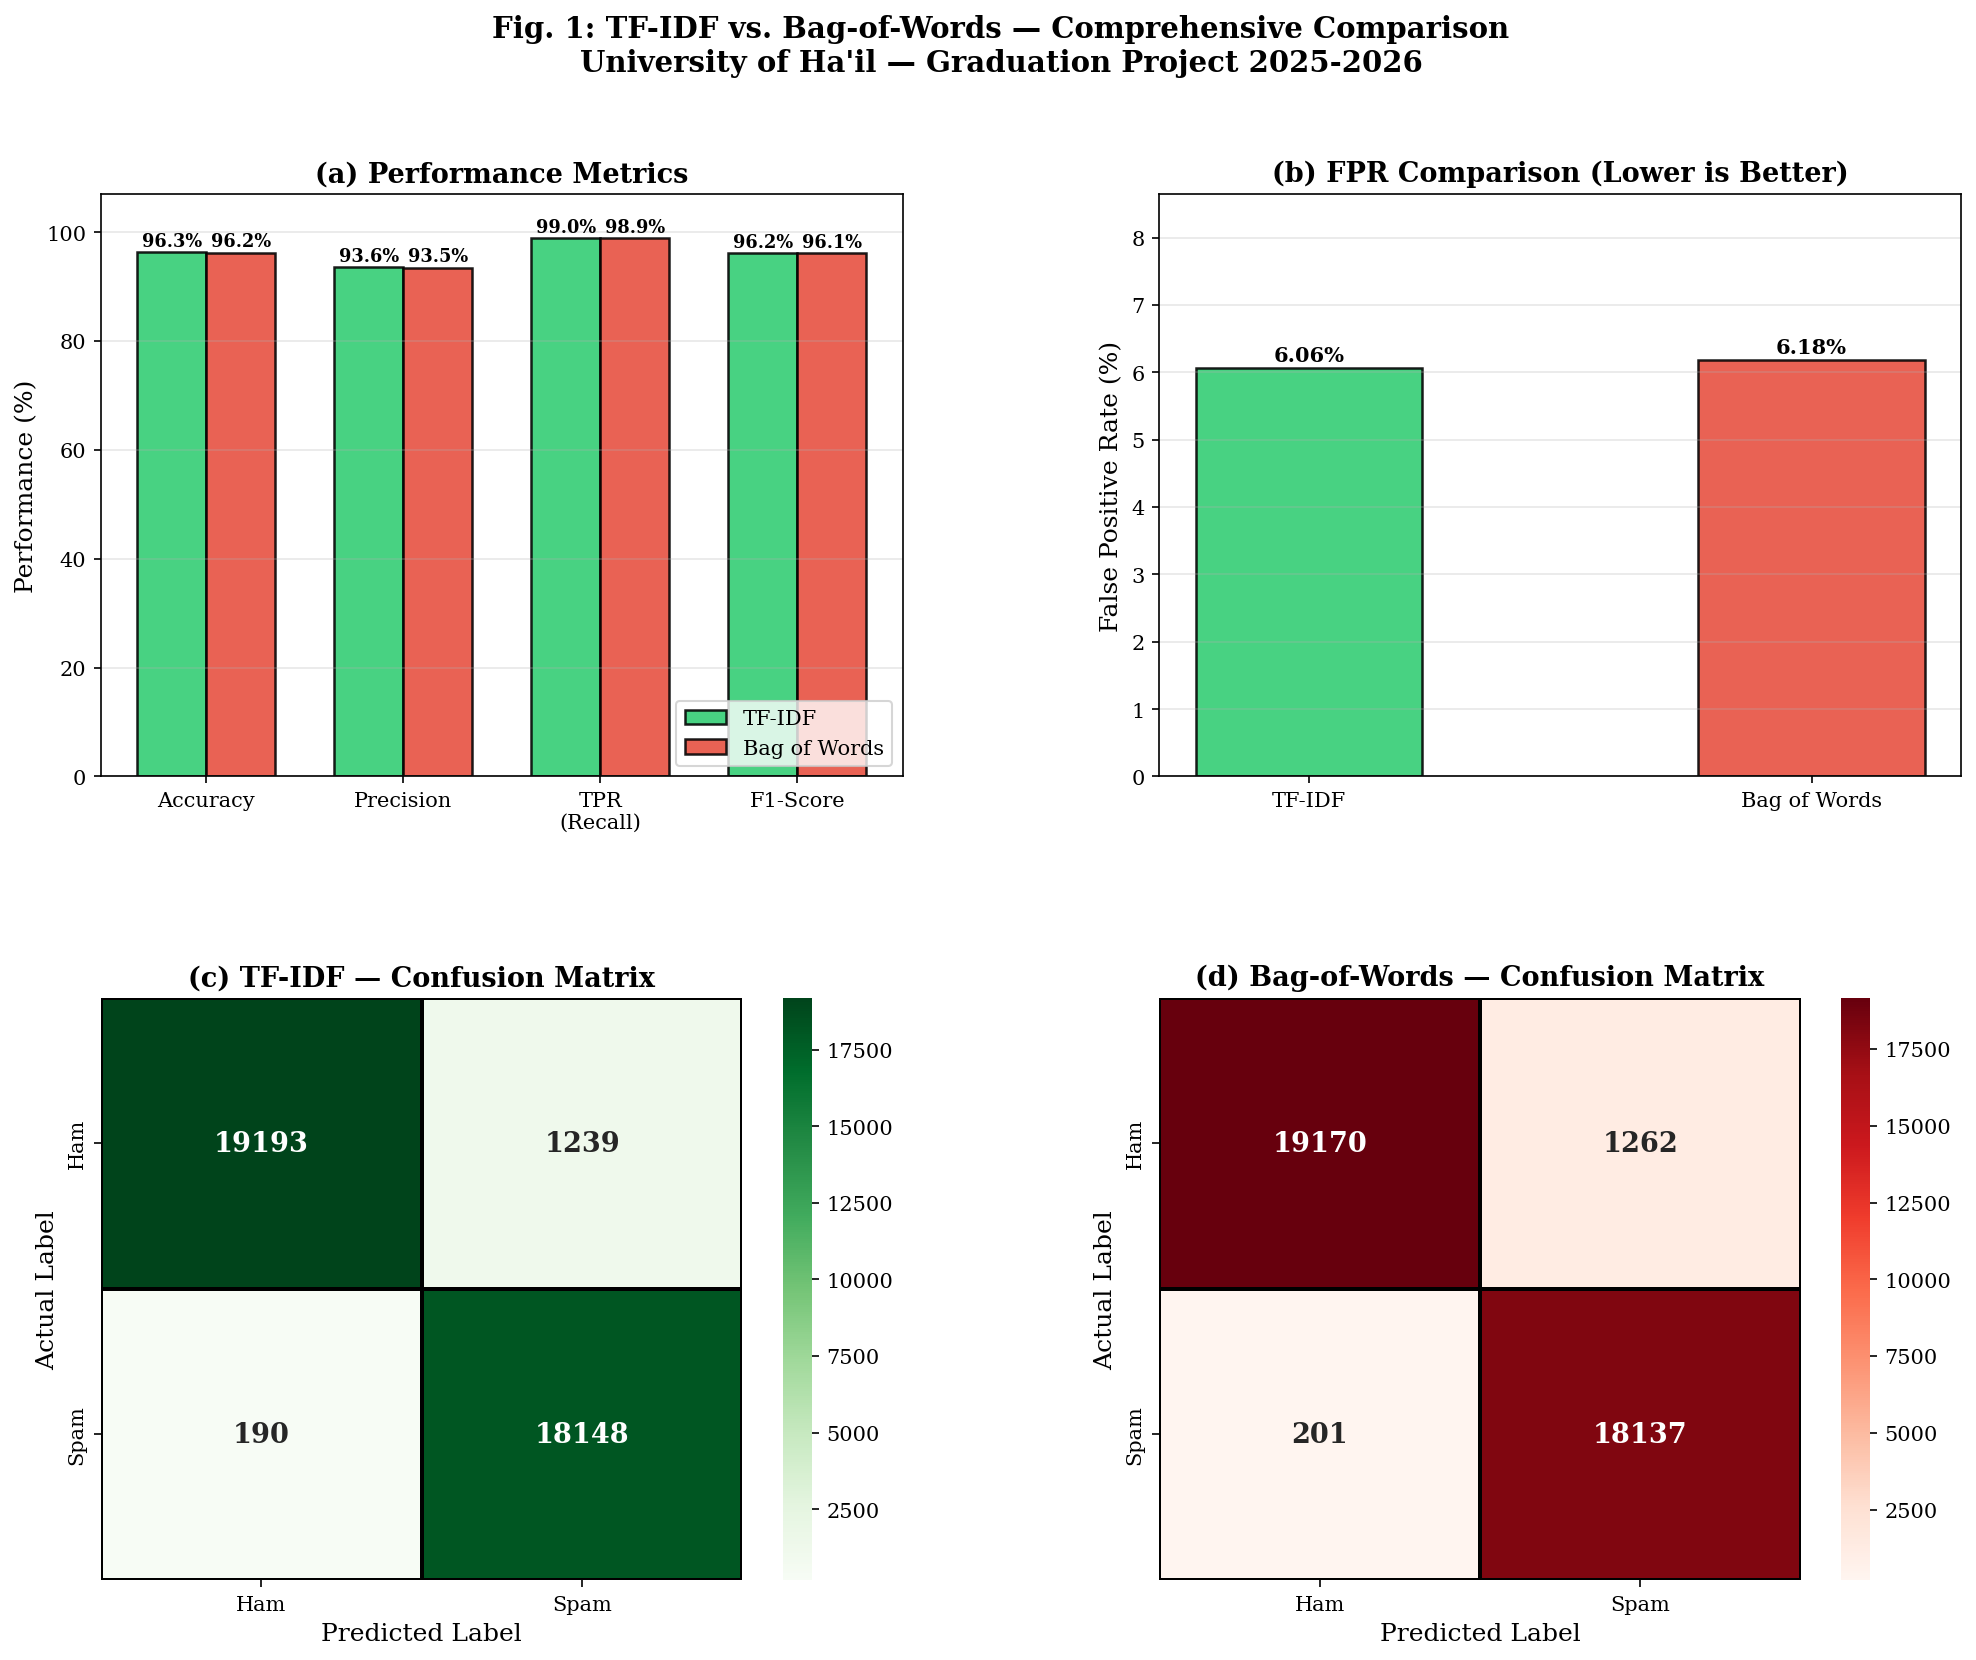

✓ Fig. 1 saved


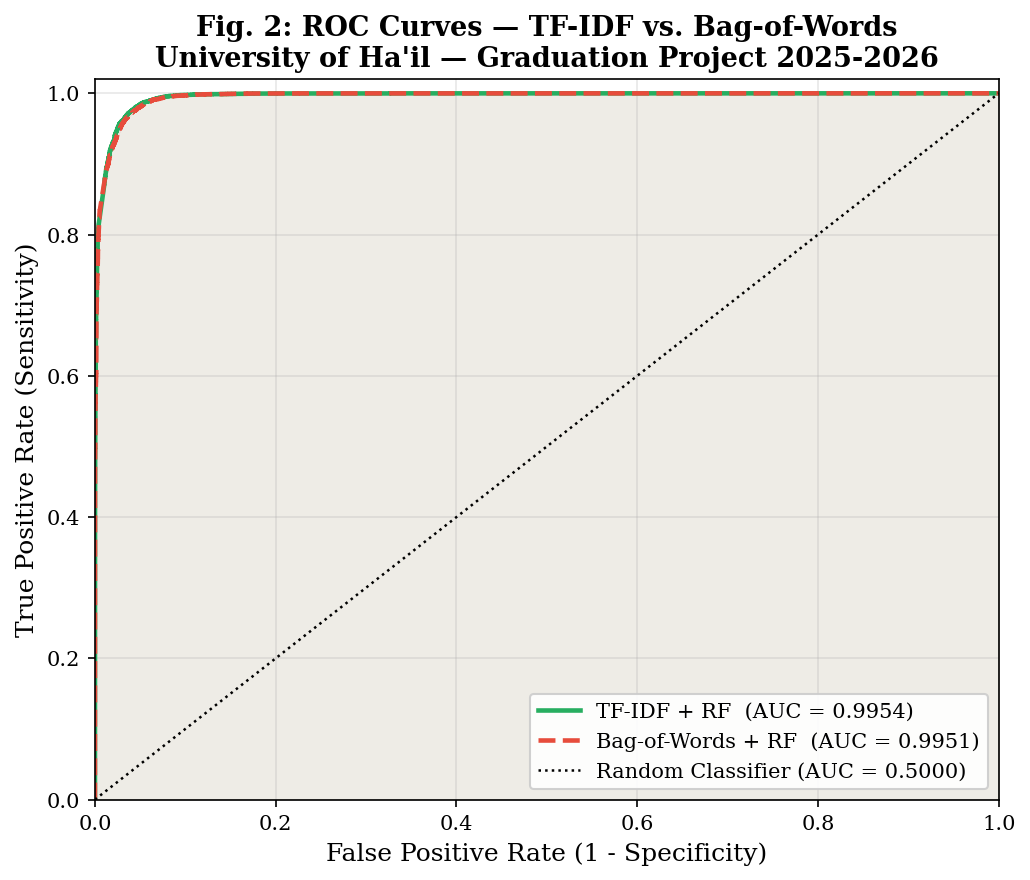

✓ Fig. 2 saved


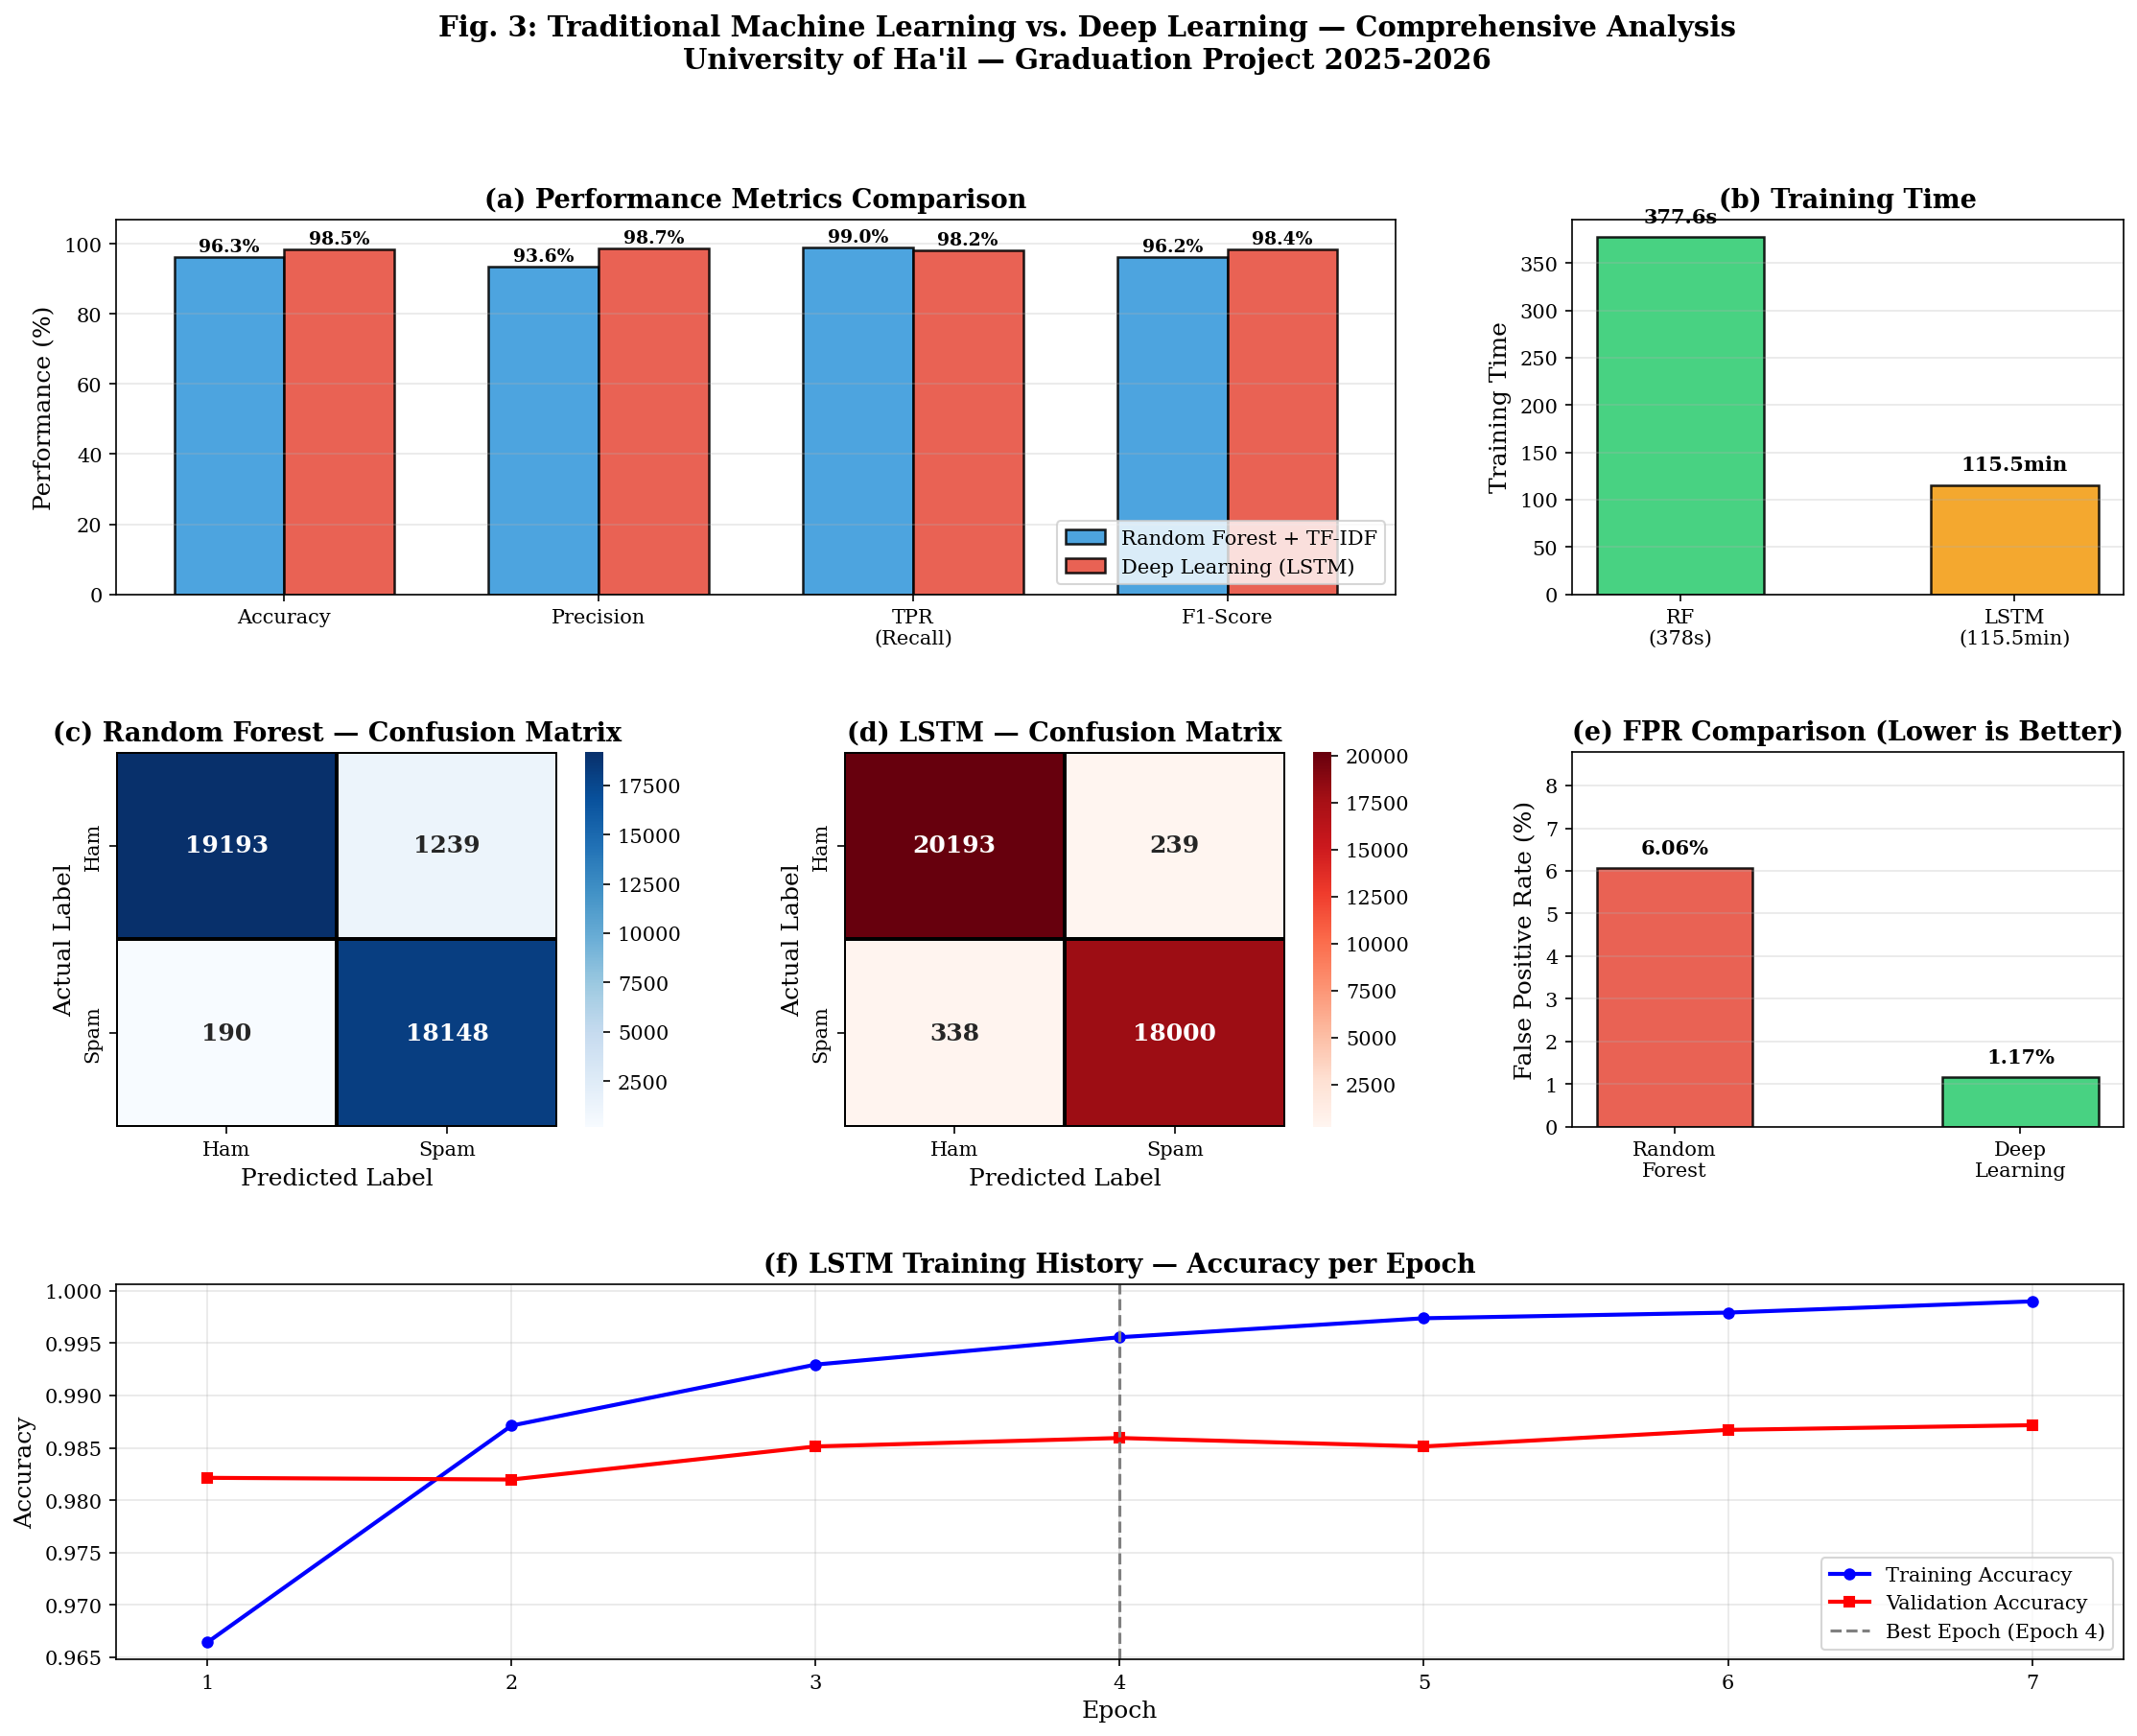

✓ Fig. 3 saved


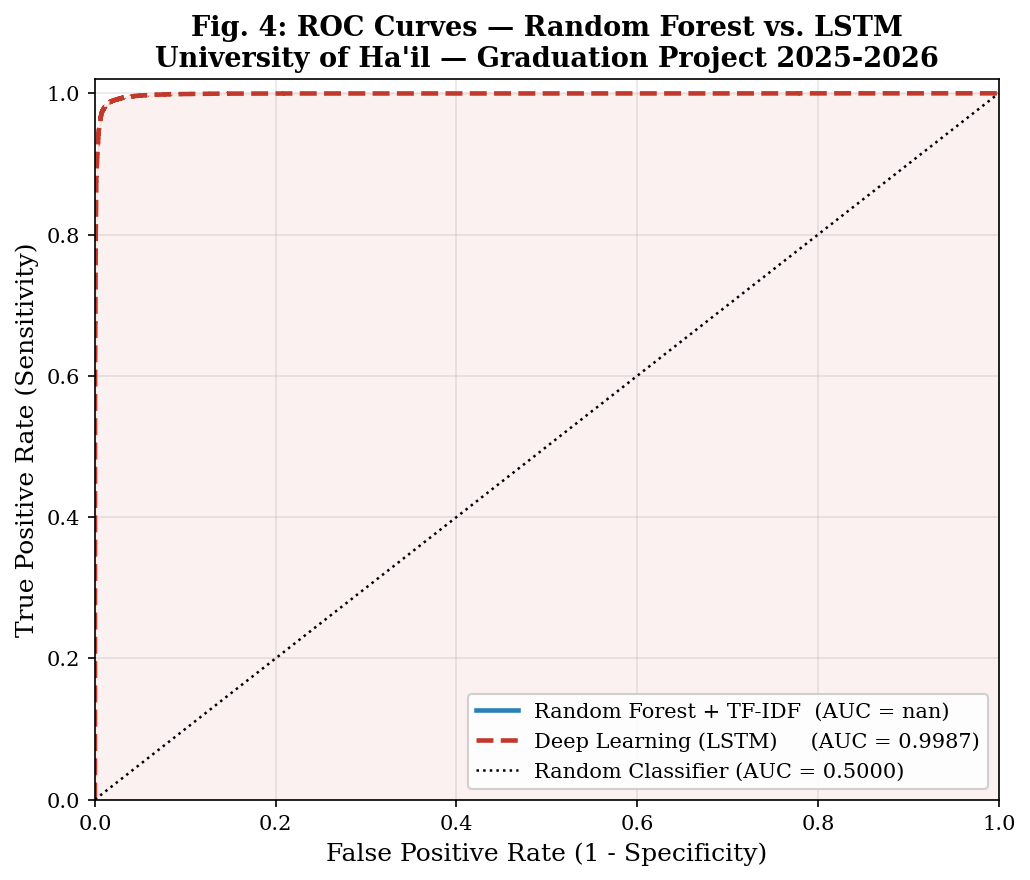

✓ Fig. 4 saved


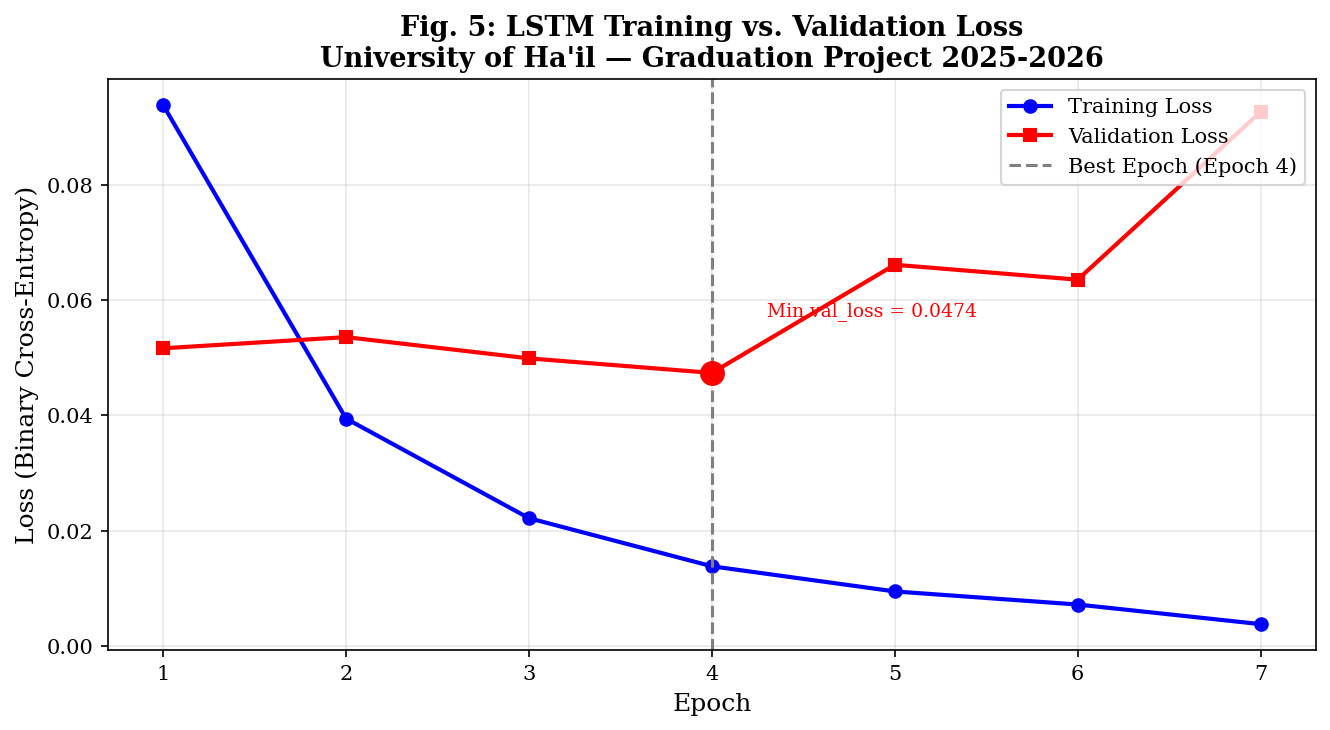

✓ Fig. 5 saved

💾 Saving models and data...

📥 Downloading all files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ DONE — كل شيء محفوظ!

Method                     Accuracy     FPR      AUC       Time
-----------------------------------------------------------------
Bag-of-Words + RF            96.23%   6.18%    N/A      376s
TF-IDF + RF                  96.31%   6.06% nan      378s
LSTM (Deep Learning)         98.51%   1.17% 0.9987   115.5min

🏆 Best Accuracy : LSTM (98.51%)
🏆 Lowest FPR    : LSTM
🏆 Fastest Train : TF-IDF+RF (378s)

📁 للفرونت إند احتاج: lstm_spam_model.h5 + tokenizer.pkl


In [1]:
# ================================================================
# COMPLETE SPAM DETECTION - ALL TASKS IN ONE
# University of Ha'il - Information Security Department
# Graduation Project 2025-2026
# Team: Majed, Talal, Mazen, Yazeed, Dhari
# Supervisor: Dr. Shahid Alam
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time, re, warnings, pickle
warnings.filterwarnings('ignore')


plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                     Bidirectional, GlobalMaxPooling1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from google.colab import files

TITLE_SUFFIX = "University of Ha'il — Graduation Project 2025-2026"

# ══════════════════════════════════════════════════════════════
# STEP 1: تحميل الداتا
# ══════════════════════════════════════════════════════════════
print("📤 ارفع ملف الـ CSV...")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

label_col, text_col = None, None
for col in df.columns:
    if 'label' in col.lower() or 'category' in col.lower(): label_col = col
    if 'message' in col.lower() or 'text' in col.lower() or 'email' in col.lower(): text_col = col

df_clean = df[[label_col, text_col]].copy()
df_clean.columns = ['label', 'text']
df_clean = df_clean.dropna().drop_duplicates()
df_clean['label'] = df_clean['label'].astype(str).str.lower().str.strip()
label_mapping = {l: ('spam' if 'spam' in l or l=='1' else 'ham') for l in df_clean['label'].unique()}
df_clean['label'] = df_clean['label'].map(label_mapping)
df_clean['label_binary'] = (df_clean['label'] == 'spam').astype(int)
df_clean['text_length'] = df_clean['text'].astype(str).apply(len)
df_clean['word_count']  = df_clean['text'].astype(str).apply(lambda x: len(x.split()))
print(f"✓ Dataset: {len(df_clean):,} | Spam: {df_clean['label_binary'].sum():,} | Ham: {(df_clean['label_binary']==0).sum():,}")

# ══════════════════════════════════════════════════════════════
# STEP 2: NLP Preprocessing
# ══════════════════════════════════════════════════════════════
def preprocess_nlp(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\+?\d[\d\s\-]{8,}\d', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return ' '.join(text.split())

df_clean['text_processed'] = df_clean['text'].apply(preprocess_nlp)
print("✓ NLP preprocessing done")

# ══════════════════════════════════════════════════════════════
# STEP 3: Split
# ══════════════════════════════════════════════════════════════
X_raw = df_clean['text']
X_nlp = df_clean['text_processed']
y_str = df_clean['label']
y_bin = df_clean['label_binary']

X_train_raw, X_test_raw, y_train_str, y_test_str = train_test_split(
    X_raw, y_str, test_size=0.2, random_state=42, stratify=y_str)
X_train_nlp, X_test_nlp, y_train_bin, y_test_bin = train_test_split(
    X_nlp, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

# ══════════════════════════════════════════════════════════════
# STEP 4: TF-IDF + RF
# ══════════════════════════════════════════════════════════════
print("\n⏳ Training TF-IDF + Random Forest...")
t0 = time.time()
tfidf_vec = TfidfVectorizer(max_features=5000, stop_words='english',
                             ngram_range=(1,2), min_df=3, max_df=0.8)
X_train_tfidf = tfidf_vec.fit_transform(X_train_raw)
X_test_tfidf  = tfidf_vec.transform(X_test_raw)
rf_tfidf = RandomForestClassifier(n_estimators=100, max_depth=50, random_state=42, n_jobs=-1)
rf_tfidf.fit(X_train_tfidf, y_train_str)
time_tfidf = time.time() - t0

y_pred_tfidf  = rf_tfidf.predict(X_test_tfidf)
cm_tfidf      = confusion_matrix(y_test_str, y_pred_tfidf, labels=['ham','spam'])
tn_t,fp_t,fn_t,tp_t = cm_tfidf.ravel()
acc_tfidf  = accuracy_score(y_test_str, y_pred_tfidf)
prec_tfidf = precision_score(y_test_str, y_pred_tfidf, pos_label='spam')
rec_tfidf  = recall_score(y_test_str, y_pred_tfidf, pos_label='spam')
f1_tfidf   = f1_score(y_test_str, y_pred_tfidf, pos_label='spam')
fpr_tfidf  = fp_t/(fp_t+tn_t)
print(f"✓ TF-IDF: Acc={acc_tfidf*100:.2f}% | FPR={fpr_tfidf*100:.2f}% | Time={time_tfidf:.0f}s")

# ══════════════════════════════════════════════════════════════
# STEP 5: BoW + RF
# ══════════════════════════════════════════════════════════════
print("⏳ Training BoW + Random Forest...")
t0 = time.time()
bow_vec = CountVectorizer(max_features=5000, stop_words='english',
                           ngram_range=(1,2), min_df=3, max_df=0.8)
X_train_bow = bow_vec.fit_transform(X_train_raw)
X_test_bow  = bow_vec.transform(X_test_raw)
rf_bow = RandomForestClassifier(n_estimators=100, max_depth=50, random_state=42, n_jobs=-1)
rf_bow.fit(X_train_bow, y_train_str)
time_bow = time.time() - t0

y_pred_bow  = rf_bow.predict(X_test_bow)
cm_bow      = confusion_matrix(y_test_str, y_pred_bow, labels=['ham','spam'])
tn_b,fp_b,fn_b,tp_b = cm_bow.ravel()
acc_bow  = accuracy_score(y_test_str, y_pred_bow)
prec_bow = precision_score(y_test_str, y_pred_bow, pos_label='spam')
rec_bow  = recall_score(y_test_str, y_pred_bow, pos_label='spam')
f1_bow   = f1_score(y_test_str, y_pred_bow, pos_label='spam')
fpr_bow  = fp_b/(fp_b+tn_b)
print(f"✓ BoW:    Acc={acc_bow*100:.2f}% | FPR={fpr_bow*100:.2f}% | Time={time_bow:.0f}s")

# ══════════════════════════════════════════════════════════════
# STEP 6: LSTM
# ══════════════════════════════════════════════════════════════
print("⏳ Training LSTM...")
MAX_WORDS, MAX_LEN = 10000, 200
tokenizer_lstm = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer_lstm.fit_on_texts(X_train_nlp)
X_train_pad = pad_sequences(tokenizer_lstm.texts_to_sequences(X_train_nlp),
                             maxlen=MAX_LEN, padding='post')
X_test_pad  = pad_sequences(tokenizer_lstm.texts_to_sequences(X_test_nlp),
                             maxlen=MAX_LEN, padding='post')

model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'), Dropout(0.5),
    Dense(32, activation='relu'), Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

t0 = time.time()
history = model.fit(
    X_train_pad, y_train_bin,
    batch_size=32, epochs=20, validation_split=0.2, verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    ]
)
time_lstm = time.time() - t0

y_prob_lstm = model.predict(X_test_pad, verbose=0).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)
cm_lstm     = confusion_matrix(y_test_bin, y_pred_lstm)
tn_l,fp_l,fn_l,tp_l = cm_lstm.ravel()
acc_lstm  = accuracy_score(y_test_bin, y_pred_lstm)
prec_lstm = precision_score(y_test_bin, y_pred_lstm)
rec_lstm  = recall_score(y_test_bin, y_pred_lstm)
f1_lstm   = f1_score(y_test_bin, y_pred_lstm)
fpr_lstm  = fp_l/(fp_l+tn_l)
print(f"✓ LSTM:   Acc={acc_lstm*100:.2f}% | FPR={fpr_lstm*100:.2f}% | Time={time_lstm/60:.1f}min")

# ══════════════════════════════════════════════════════════════
# FIGURE 1: TF-IDF vs Bag of Words Comprehensive Comparison
# (confusion matrices + performance + FPR)
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    f'Fig. 1: TF-IDF vs. Bag-of-Words — Comprehensive Comparison\n{TITLE_SUFFIX}',
    fontsize=14, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# (a) Performance metrics
ax_a = fig.add_subplot(gs[0, 0])
metrics_names = ['Accuracy', 'Precision', 'TPR\n(Recall)', 'F1-Score']
vals_tfidf = [acc_tfidf*100, prec_tfidf*100, rec_tfidf*100, f1_tfidf*100]
vals_bow   = [acc_bow*100,   prec_bow*100,   rec_bow*100,   f1_bow*100]
x = np.arange(len(metrics_names)); w = 0.35
b1 = ax_a.bar(x-w/2, vals_tfidf, w, label='TF-IDF',       color='#2ecc71', edgecolor='black', linewidth=1.2, alpha=0.88)
b2 = ax_a.bar(x+w/2, vals_bow,   w, label='Bag of Words', color='#e74c3c', edgecolor='black', linewidth=1.2, alpha=0.88)
for bars in [b1, b2]:
    for bar in bars:
        ax_a.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                  f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax_a.set_xticks(x); ax_a.set_xticklabels(metrics_names)
ax_a.set_ylabel('Performance (%)'); ax_a.set_ylim(0, 107)
ax_a.set_title('(a) Performance Metrics', fontweight='bold')
ax_a.legend(loc='lower right'); ax_a.grid(axis='y', alpha=0.3)

# (b) FPR comparison
ax_b = fig.add_subplot(gs[0, 1])
fpr_colors = ['#2ecc71' if fpr_tfidf < fpr_bow else '#e74c3c',
               '#e74c3c' if fpr_tfidf < fpr_bow else '#2ecc71']
bars_fpr = ax_b.bar(['TF-IDF', 'Bag of Words'], [fpr_tfidf*100, fpr_bow*100],
                    color=fpr_colors, edgecolor='black', linewidth=1.2, alpha=0.88, width=0.45)
for i, v in enumerate([fpr_tfidf*100, fpr_bow*100]):
    ax_b.text(i, v+0.05, f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax_b.set_ylabel('False Positive Rate (%)')
ax_b.set_title('(b) FPR Comparison (Lower is Better)', fontweight='bold')
ax_b.set_ylim(0, max(fpr_tfidf, fpr_bow)*100*1.4)
ax_b.grid(axis='y', alpha=0.3)

# (c) TF-IDF Confusion Matrix
ax_c = fig.add_subplot(gs[1, 0])
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'],
            ax=ax_c, cbar=True, linewidths=1, linecolor='black',
            annot_kws={'size':13,'weight':'bold'})
ax_c.set_title('(c) TF-IDF — Confusion Matrix', fontweight='bold')
ax_c.set_xlabel('Predicted Label'); ax_c.set_ylabel('Actual Label')

# (d) BoW Confusion Matrix
ax_d = fig.add_subplot(gs[1, 1])
sns.heatmap(cm_bow, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'],
            ax=ax_d, cbar=True, linewidths=1, linecolor='black',
            annot_kws={'size':13,'weight':'bold'})
ax_d.set_title('(d) Bag-of-Words — Confusion Matrix', fontweight='bold')
ax_d.set_xlabel('Predicted Label'); ax_d.set_ylabel('Actual Label')

plt.savefig('fig1_tfidf_vs_bow.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Fig. 1 saved")

# ══════════════════════════════════════════════════════════════
# FIGURE 2: ROC Curves — TF-IDF vs BoW
# ( ROC + AUC)
# ══════════════════════════════════════════════════════════════
fpr_r_t, tpr_r_t, _ = roc_curve(y_test_str, rf_tfidf.predict_proba(X_test_tfidf)[:,1], pos_label='spam')
fpr_r_b, tpr_r_b, _ = roc_curve(y_test_str, rf_bow.predict_proba(X_test_bow)[:,1],     pos_label='spam')
auc_t = auc(fpr_r_t, tpr_r_t)
auc_b = auc(fpr_r_b, tpr_r_b)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_r_t, tpr_r_t, color='#27ae60', lw=2.2, label=f'TF-IDF + RF  (AUC = {auc_t:.4f})')
ax.plot(fpr_r_b, tpr_r_b, color='#e74c3c', lw=2.2, linestyle='--', label=f'Bag-of-Words + RF  (AUC = {auc_b:.4f})')
ax.plot([0,1],[0,1], 'k:', lw=1.2, label='Random Classifier (AUC = 0.5000)')
ax.fill_between(fpr_r_t, tpr_r_t, alpha=0.07, color='#27ae60')
ax.fill_between(fpr_r_b, tpr_r_b, alpha=0.07, color='#e74c3c')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title(f'Fig. 2: ROC Curves — TF-IDF vs. Bag-of-Words\n{TITLE_SUFFIX}', fontweight='bold')
ax.legend(loc='lower right', framealpha=0.9)
ax.grid(alpha=0.3); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig('fig2_roc_tfidf_vs_bow.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Fig. 2 saved")

# ══════════════════════════════════════════════════════════════
# FIGURE 3: ML vs Deep Learning Comprehensive Analysis
# ( confusion matrices + performance + FPR + training time + LSTM history)
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 13))
fig.suptitle(
    f'Fig. 3: Traditional Machine Learning vs. Deep Learning — Comprehensive Analysis\n{TITLE_SUFFIX}',
    fontsize=14, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.32)

# (a) Performance metrics
ax1 = fig.add_subplot(gs[0, :2])
m_names = ['Accuracy', 'Precision', 'TPR\n(Recall)', 'F1-Score']
rf_scores   = [acc_tfidf*100, prec_tfidf*100, rec_tfidf*100, f1_tfidf*100]
lstm_scores = [acc_lstm*100,  prec_lstm*100,  rec_lstm*100,  f1_lstm*100]
x = np.arange(len(m_names)); w = 0.35
b1 = ax1.bar(x-w/2, rf_scores,   w, label='Random Forest + TF-IDF', color='#3498db', edgecolor='black', linewidth=1.2, alpha=0.88)
b2 = ax1.bar(x+w/2, lstm_scores, w, label='Deep Learning (LSTM)',   color='#e74c3c', edgecolor='black', linewidth=1.2, alpha=0.88)
for bars in [b1, b2]:
    for bar in bars:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(m_names)
ax1.set_ylabel('Performance (%)'); ax1.set_ylim(0, 107)
ax1.set_title('(a) Performance Metrics Comparison', fontweight='bold')
ax1.legend(loc='lower right'); ax1.grid(axis='y', alpha=0.3)

# (b) Training time
ax2 = fig.add_subplot(gs[0, 2])
time_vals  = [time_tfidf, time_lstm/60]
time_lbls  = [f'RF\n({time_tfidf:.0f}s)', f'LSTM\n({time_lstm/60:.1f}min)']
time_cols  = ['#2ecc71', '#f39c12']
bars_t = ax2.bar(time_lbls, time_vals, color=time_cols, edgecolor='black', linewidth=1.2, alpha=0.88, width=0.5)
for bar, val, unit in zip(bars_t, time_vals, ['s','min']):
    ax2.text(bar.get_x()+bar.get_width()/2, val+max(time_vals)*0.03,
             f'{val:.1f}{unit}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax2.set_ylabel('Training Time'); ax2.set_title('(b) Training Time', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# (c) RF Confusion Matrix
ax3 = fig.add_subplot(gs[1, 0])
sns.heatmap(confusion_matrix(y_test_str, y_pred_tfidf, labels=['ham','spam']),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'],
            ax=ax3, cbar=True, linewidths=1, linecolor='black',
            annot_kws={'size':12,'weight':'bold'})
ax3.set_title('(c) Random Forest — Confusion Matrix', fontweight='bold')
ax3.set_xlabel('Predicted Label'); ax3.set_ylabel('Actual Label')

# (d) LSTM Confusion Matrix
ax4 = fig.add_subplot(gs[1, 1])
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'],
            ax=ax4, cbar=True, linewidths=1, linecolor='black',
            annot_kws={'size':12,'weight':'bold'})
ax4.set_title('(d) LSTM — Confusion Matrix', fontweight='bold')
ax4.set_xlabel('Predicted Label'); ax4.set_ylabel('Actual Label')

# (e) FPR comparison
ax5 = fig.add_subplot(gs[1, 2])
fpr_vals = [fpr_tfidf*100, fpr_lstm*100]
fpr_cols = ['#2ecc71' if fpr_tfidf < fpr_lstm else '#e74c3c',
            '#e74c3c' if fpr_tfidf < fpr_lstm else '#2ecc71']
bars_f = ax5.bar(['Random\nForest', 'Deep\nLearning'], fpr_vals,
                  color=fpr_cols, edgecolor='black', linewidth=1.2, alpha=0.88, width=0.45)
for i, v in enumerate(fpr_vals):
    ax5.text(i, v+max(fpr_vals)*0.04, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax5.set_ylabel('False Positive Rate (%)')
ax5.set_title('(e) FPR Comparison (Lower is Better)', fontweight='bold')
ax5.set_ylim(0, max(fpr_vals)*1.45); ax5.grid(axis='y', alpha=0.3)

# (f) LSTM Training History
ax6 = fig.add_subplot(gs[2, :])
ep = range(1, len(history.history['loss'])+1)
best_ep  = history.history['val_loss'].index(min(history.history['val_loss']))+1
best_val = min(history.history['val_loss'])
ax6.plot(ep, history.history['accuracy'],     'b-o', lw=2, markersize=5, label='Training Accuracy')
ax6.plot(ep, history.history['val_accuracy'], 'r-s', lw=2, markersize=5, label='Validation Accuracy')
ax6.axvline(x=best_ep, color='gray', linestyle='--', lw=1.5, label=f'Best Epoch (Epoch {best_ep})')
ax6.set_xlabel('Epoch'); ax6.set_ylabel('Accuracy')
ax6.set_title('(f) LSTM Training History — Accuracy per Epoch', fontweight='bold')
ax6.legend(loc='lower right'); ax6.grid(alpha=0.3); ax6.set_xticks(list(ep))

plt.savefig('fig3_ml_vs_dl.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Fig. 3 saved")

# ══════════════════════════════════════════════════════════════
# FIGURE 4: ROC Curves — RF vs LSTM
# ( ROC + AUC)
# ══════════════════════════════════════════════════════════════
fpr_r_rf,   tpr_r_rf,   _ = roc_curve(y_test_bin, rf_tfidf.predict_proba(X_test_tfidf)[:,1], pos_label='spam')
fpr_r_lstm, tpr_r_lstm, _ = roc_curve(y_test_bin, y_prob_lstm)
auc_rf   = auc(fpr_r_rf,   tpr_r_rf)
auc_lstm_roc = auc(fpr_r_lstm, tpr_r_lstm)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_r_rf,   tpr_r_rf,   color='#2980b9', lw=2.2, label=f'Random Forest + TF-IDF  (AUC = {auc_rf:.4f})')
ax.plot(fpr_r_lstm, tpr_r_lstm, color='#c0392b', lw=2.2, linestyle='--', label=f'Deep Learning (LSTM)     (AUC = {auc_lstm_roc:.4f})')
ax.plot([0,1],[0,1], 'k:', lw=1.2, label='Random Classifier (AUC = 0.5000)')
ax.fill_between(fpr_r_rf,   tpr_r_rf,   alpha=0.07, color='#2980b9')
ax.fill_between(fpr_r_lstm, tpr_r_lstm, alpha=0.07, color='#c0392b')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title(f'Fig. 4: ROC Curves — Random Forest vs. LSTM\n{TITLE_SUFFIX}', fontweight='bold')
ax.legend(loc='lower right', framealpha=0.9)
ax.grid(alpha=0.3); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig('fig4_roc_rf_vs_lstm.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Fig. 4 saved")

# ══════════════════════════════════════════════════════════════
# FIGURE 5: Epoch vs Loss
# ( training curve)
# ══════════════════════════════════════════════════════════════
ep = range(1, len(history.history['loss'])+1)
best_ep  = history.history['val_loss'].index(min(history.history['val_loss']))+1
best_val = min(history.history['val_loss'])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ep, history.history['loss'],     'b-o', lw=2, markersize=6, label='Training Loss')
ax.plot(ep, history.history['val_loss'], 'r-s', lw=2, markersize=6, label='Validation Loss')
ax.axvline(x=best_ep, color='gray', linestyle='--', lw=1.5, label=f'Best Epoch (Epoch {best_ep})')
ax.scatter([best_ep], [best_val], color='red', s=120, zorder=5)
ax.annotate(f'Min val_loss = {best_val:.4f}',
            xy=(best_ep, best_val), xytext=(best_ep+0.3, best_val+0.01),
            fontsize=9, color='red')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (Binary Cross-Entropy)')
ax.set_title(f'Fig. 5: LSTM Training vs. Validation Loss\n{TITLE_SUFFIX}', fontweight='bold')
ax.legend(loc='upper right'); ax.set_xticks(list(ep)); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig5_epoch_vs_loss.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Fig. 5 saved")

# ══════════════════════════════════════════════════════════════
# SAVE ALL
# ══════════════════════════════════════════════════════════════
print("\n💾 Saving models and data...")
model.save('lstm_spam_model.h5')
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer_lstm, f)

np.save('y_test_str.npy',  np.array(list(y_test_str)))
np.save('y_test_bin.npy',  np.array(list(y_test_bin)))
np.save('proba_tfidf.npy', rf_tfidf.predict_proba(X_test_tfidf)[:,1])
np.save('proba_bow.npy',   rf_bow.predict_proba(X_test_bow)[:,1])
np.save('proba_lstm.npy',  y_prob_lstm)
np.save('loss_train.npy',  np.array(history.history['loss']))
np.save('loss_val.npy',    np.array(history.history['val_loss']))

print("\n📥 Downloading all files...")
for fname in ['fig1_tfidf_vs_bow.png', 'fig2_roc_tfidf_vs_bow.png',
              'fig3_ml_vs_dl.png',     'fig4_roc_rf_vs_lstm.png',
              'fig5_epoch_vs_loss.png',
              'lstm_spam_model.h5',    'tokenizer.pkl',
              'y_test_str.npy',        'y_test_bin.npy',
              'proba_tfidf.npy',       'proba_bow.npy',
              'proba_lstm.npy',        'loss_train.npy', 'loss_val.npy']:
    files.download(fname)

print("\n" + "="*65)
print("✅ DONE — كل شيء محفوظ!")
print(f"\n{'Method':<25} {'Accuracy':>9} {'FPR':>7} {'AUC':>8} {'Time':>10}")
print("-"*65)
print(f"{'Bag-of-Words + RF':<25} {acc_bow*100:>8.2f}% {fpr_bow*100:>6.2f}%    N/A {time_bow:>8.0f}s")
print(f"{'TF-IDF + RF':<25} {acc_tfidf*100:>8.2f}% {fpr_tfidf*100:>6.2f}% {auc_rf:.4f} {time_tfidf:>8.0f}s")
print(f"{'LSTM (Deep Learning)':<25} {acc_lstm*100:>8.2f}% {fpr_lstm*100:>6.2f}% {auc_lstm_roc:.4f} {time_lstm/60:>7.1f}min")
print("="*65)
print(f"\n🏆 Best Accuracy : LSTM ({acc_lstm*100:.2f}%)")
print(f"🏆 Lowest FPR    : {'LSTM' if fpr_lstm < fpr_tfidf else 'TF-IDF'}")
print(f"🏆 Fastest Train : TF-IDF+RF ({time_tfidf:.0f}s)")
print(f"\n📁 للفرونت إند احتاج: lstm_spam_model.h5 + tokenizer.pkl")
print("="*65)

In [2]:
import pickle
import numpy as np
from google.colab import files

# حفظ النتائج
np.save('y_test_str.npy',  np.array(list(y_test_str)))
np.save('y_test_bin.npy',  np.array(list(y_test_bin)))
np.save('proba_tfidf.npy', rf_tfidf.predict_proba(X_test_tfidf)[:,1])
np.save('proba_bow.npy',   rf_bow.predict_proba(X_test_bow)[:,1])
np.save('proba_lstm.npy',  y_prob_lstm)
np.save('loss_train.npy',  np.array(history.history['loss']))
np.save('loss_val.npy',    np.array(history.history['val_loss']))

# حفظ النموذج
model.save('lstm_spam_model.h5')
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer_lstm, f)

# تنزيل كل شيء
for fname in ['lstm_spam_model.h5', 'tokenizer.pkl',
              'y_test_str.npy', 'y_test_bin.npy',
              'proba_tfidf.npy', 'proba_bow.npy',
              'proba_lstm.npy', 'loss_train.npy', 'loss_val.npy']:
    files.download(fname)

print("✓ كل شيء محفوظ ومنزّل")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ كل شيء محفوظ ومنزّل


In [3]:
import numpy as np
import pickle
import tensorflow as tf

print("🔍 فحص الملفات المحفوظة...\n")

# فحص النموذج
try:
    model_test = tf.keras.models.load_model('lstm_spam_model.h5')
    print("✅ lstm_spam_model.h5 — سليم")
except:
    print("❌ lstm_spam_model.h5 — مفقود أو خطأ")

# فحص التوكنايزر
try:
    with open('tokenizer.pkl', 'rb') as f:
        tok = pickle.load(f)
    print("✅ tokenizer.pkl — سليم")
except:
    print("❌ tokenizer.pkl — مفقود أو خطأ")

# فحص النتائج
files_npy = ['y_test_str.npy','y_test_bin.npy',
             'proba_tfidf.npy','proba_bow.npy','proba_lstm.npy',
             'loss_train.npy','loss_val.npy']
for f in files_npy:
    try:
        d = np.load(f, allow_pickle=True)
        print(f"✅ {f} — {len(d):,} قيمة")
    except:
        print(f"❌ {f} — مفقود")

print("\n✅ كل شيء جاهز — ما تحتاج تدريب بعد كذا")

🔍 فحص الملفات المحفوظة...



✅ lstm_spam_model.h5 — سليم
✅ tokenizer.pkl — سليم
✅ y_test_str.npy — 38,770 قيمة
✅ y_test_bin.npy — 38,770 قيمة
✅ proba_tfidf.npy — 38,770 قيمة
✅ proba_bow.npy — 38,770 قيمة
✅ proba_lstm.npy — 38,770 قيمة
✅ loss_train.npy — 7 قيمة
✅ loss_val.npy — 7 قيمة

✅ كل شيء جاهز — ما تحتاج تدريب بعد كذا
